In [1]:
# 01_eda_overview.ipynb
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

DB = "../data/lottery_star.db"
con = sqlite3.connect(DB)

# quick look at schema
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
tables


,name
0,dim_game
1,dim_session
2,dim_date
3,fact_set_draws
4,fact_set_numbers
5,fact_daily_draws


In [3]:
pd.read_sql("""
SELECT g.game_name, COUNT(*) AS draws
FROM fact_set_draws f
JOIN dim_game g USING (game_id)
GROUP BY 1
ORDER BY draws DESC;
""", con)


,game_name,draws
0,take5,10431
1,cash4life,2850
2,ny_lotto,2522
3,mega_millions,2450
4,powerball,1862


In [5]:
pd.read_sql("""
SELECT g.game_name, n.number, COUNT(*) AS freq
FROM fact_set_numbers n
JOIN dim_game g USING (game_id)
GROUP BY 1,2
HAVING freq > 1
ORDER BY g.game_name, freq DESC;
""", con)


,game_name,number,freq
0,cash4life,8,267
1,cash4life,57,265
2,cash4life,5,263
3,cash4life,13,262
4,cash4life,9,262
...,...,...,...
297,take5,13,1302
298,take5,14,1300
299,take5,4,1296
300,take5,28,1293


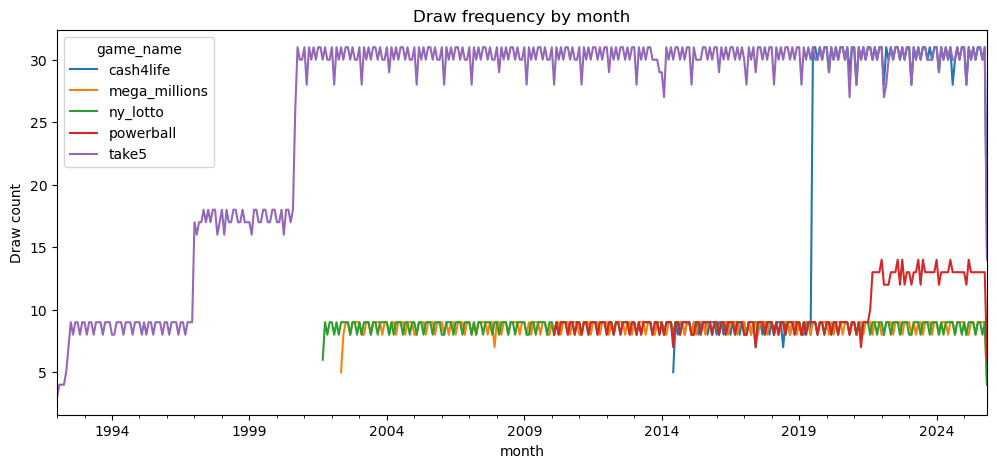

In [7]:
df = pd.read_sql("""
SELECT draw_date, g.game_name
FROM fact_set_draws f
JOIN dim_game g USING (game_id)
""", con, parse_dates=["draw_date"])

df['year'] = df['draw_date'].dt.year
df['month'] = df['draw_date'].dt.to_period('M')
df.groupby(['game_name','month']).size().unstack(0).plot(figsize=(12,5))
plt.title("Draw frequency by month")
plt.ylabel("Draw count")
plt.show()


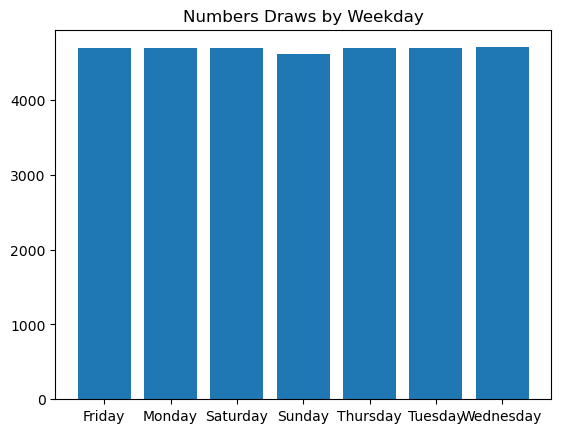

In [9]:
df_daily = pd.read_sql("""
SELECT d.weekday, COUNT(*) AS draws
FROM fact_daily_draws f
JOIN dim_date d ON f.draw_date = d.date
WHERE game_id = 6
GROUP BY 1;
""", con)
plt.bar(df_daily["weekday"], df_daily["draws"])
plt.title("Numbers Draws by Weekday")
plt.show()


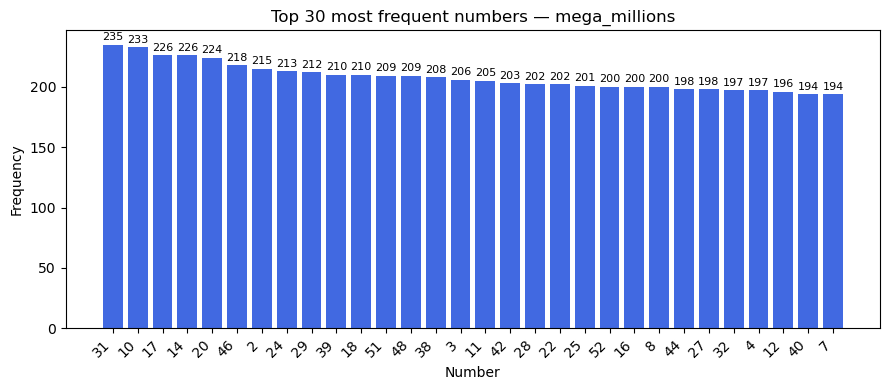

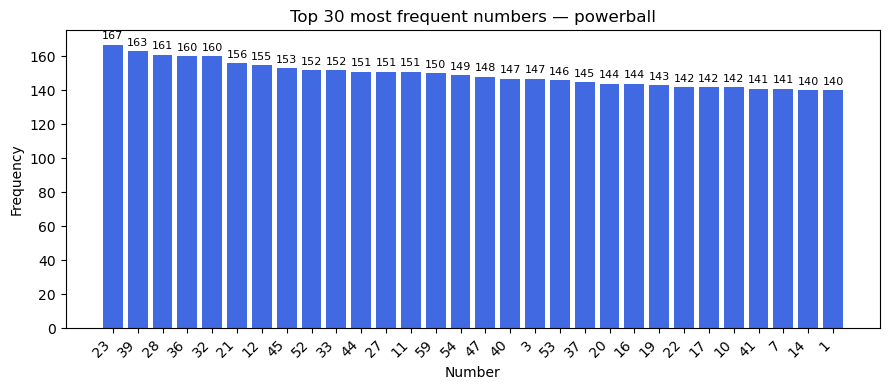

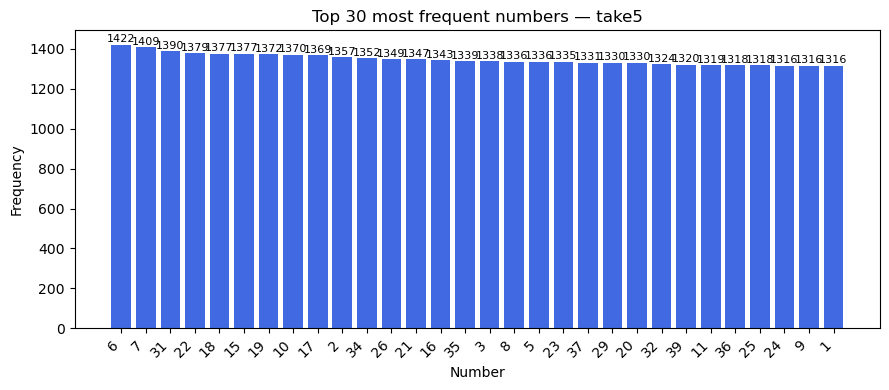

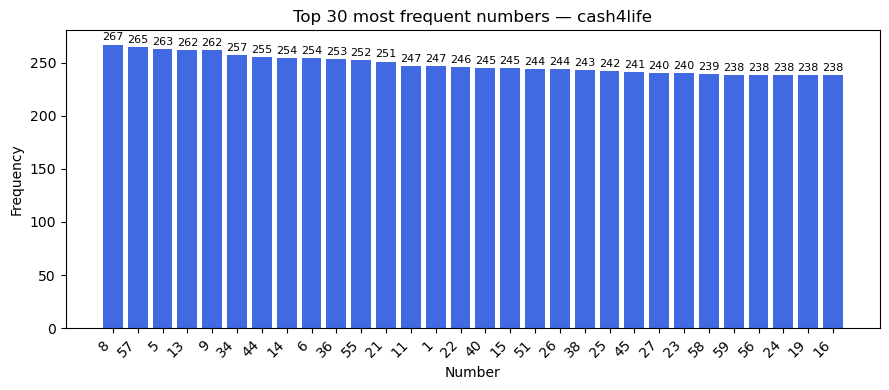

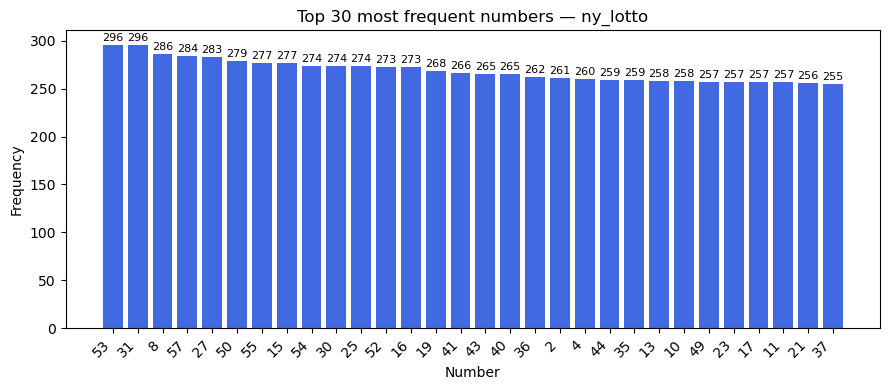

[skip] No number data for numbers
[skip] No number data for win4


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

con = sqlite3.connect("../data/lottery_star.db")

games = pd.read_sql("SELECT game_id, game_name FROM dim_game ORDER BY game_id;", con)

for _, row in games.iterrows():
    game_id = row["game_id"]
    game_name = row["game_name"]

    query = f"""
    SELECT number, COUNT(*) AS freq
    FROM fact_set_numbers
    WHERE game_id = {game_id}
    GROUP BY number
    ORDER BY freq DESC
    LIMIT 30;
    """
    df = pd.read_sql(query, con)

    if df.empty:
        print(f"[skip] No number data for {game_name}")
        continue

    df["number"] = df["number"].astype(str)

    plt.figure(figsize=(9, 4))
    bars = plt.bar(df["number"], df["freq"], color="royalblue")

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
            height + 2,                         # y position (a bit above bar)
            f"{int(height)}",                   # label text
            ha="center", va="bottom", fontsize=8
        )

    plt.title(f"Top 30 most frequent numbers — {game_name}")
    plt.xlabel("Number")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [13]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt

con = sqlite3.connect("../data/lottery_star.db")

def top_picks(game_name: str, top_n: int = 20):
    df = pd.read_sql("""
        SELECT g.game_name, f.pick, COUNT(*) AS freq
        FROM fact_daily_draws f
        JOIN dim_game g USING (game_id)
        WHERE g.game_name = ?
        GROUP BY g.game_name, f.pick
        ORDER BY freq DESC
        LIMIT ?
    """, con, params=[game_name, top_n])
    if df.empty:
        print(f"[skip] no rows for {game_name}")
        return
    df["pick"] = df["pick"].astype(str)  # categorical axis
    plt.figure(figsize=(9, 4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+1, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Top {top_n} most-repeated picks — {game_name}")
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.show()

top_picks("Numbers", top_n=20)
top_picks("Win4", top_n=20)


[skip] no rows for Numbers
[skip] no rows for Win4


In [15]:
import os, sqlite3, pandas as pd
from pathlib import Path

db_path = Path("../data/lottery_star.db").resolve()
print("DB path ->", db_path, "exists:", db_path.exists(), "size:", db_path.stat().st_size, "bytes")

con = sqlite3.connect(str(db_path))
print("fact_daily_draws rows =", pd.read_sql("SELECT COUNT(*) AS n FROM fact_daily_draws;", con).iloc[0,0])


DB path -> C:\Users\Gurram Yashaswi\OneDrive\Desktop\prep\Projects\lottery-prediction\data\lottery_star.db exists: True size: 14401536 bytes
fact_daily_draws rows = 65620


In [17]:
# Table schema
print(pd.read_sql("PRAGMA table_info(fact_daily_draws);", con))

# Distinct game_ids in fact_daily_draws
print(pd.read_sql("SELECT game_id, COUNT(*) AS cnt FROM fact_daily_draws GROUP BY game_id ORDER BY game_id;", con))

# Sample 5 rows from each game_id
print(pd.read_sql("SELECT game_id, draw_date, session_id, pick, substr(pick,1,10) AS pick_preview FROM fact_daily_draws LIMIT 5;", con))


   cid        name     type  notnull dflt_value  pk
0    0     game_id  INTEGER        1       None   1
1    1   draw_date     TEXT        1       None   2
2    2  session_id  INTEGER        1       None   3
3    3        pick     TEXT        1       None   0
4    4         sum     TEXT        0       None   0
5    5     booster     TEXT        0       None   0
   game_id    cnt
0        6  32810
1        7  32810
   game_id   draw_date  session_id pick pick_preview
0        6  2025-11-05           1  144          144
1        6  2025-11-05           2  646          646
2        6  2025-11-04           2  272          272
3        6  2025-11-04           1  684          684
4        6  2025-11-03           2  897          897


# numbers and win4 analysis

In [ ]:
def preview_daily_game(game_name: str, limit: int = 25):
    """
    Show a clean preview of a daily game (Numbers or Win4)
    with session names, latest first, plus quick stats.
    """
    # map name -> id
    gid = pd.read_sql("SELECT game_id FROM dim_game WHERE LOWER(game_name)=LOWER(?);",
                      con, params=[game_name]).squeeze()
    if pd.isna(gid):
        print(f"[err] game not found: {game_name}")
        return

    # core data
    q = """
    SELECT
        f.draw_date,
        s.session_name AS session,
        f.pick,
        f.sum,
        f.booster
    FROM fact_daily_draws f
    JOIN dim_session s USING (session_id)
    WHERE f.game_id = ?
    ORDER BY f.draw_date DESC, s.session_name DESC
    LIMIT ?;
    """
    df_preview = pd.read_sql(q, con, params=[int(gid), limit])

    # quick stats
    q_all = """
    SELECT
        MIN(draw_date) AS min_date,
        MAX(draw_date) AS max_date,
        COUNT(*)       AS rows
    FROM fact_daily_draws
    WHERE game_id = ?;
    """
    stats = pd.read_sql(q_all, con, params=[int(gid)])

    # duplicates on business key (draw_date, session)
    q_dups = """
    SELECT draw_date, session_id, COUNT(*) AS c
    FROM fact_daily_draws
    WHERE game_id = ?
    GROUP BY draw_date, session_id
    HAVING COUNT(*) > 1
    ORDER BY draw_date DESC;
    """
    dups = pd.read_sql(q_dups, con, params=[int(gid)])

    display(df_preview)
    print(f"[stats] {game_name}: rows={int(stats.loc[0,'rows'])}, "
          f"date_range={stats.loc[0,'min_date']} → {stats.loc[0,'max_date']}")
    if not dups.empty:
        print(f"[warn] duplicates found on (draw_date, session): {len(dups)} rows shown below")
        display(dups.head(10))
    else:
        print("[ok] no duplicates on (draw_date, session)")


In [ ]:
preview_daily_game("numbers", limit=25)
preview_daily_game("win4", limit=25)

,draw_date,session,pick,sum,booster
0,2025-11-07,midday,532,,
1,2025-11-07,evening,608,,
2,2025-11-06,midday,475,,
3,2025-11-06,evening,378,,
4,2025-11-05,midday,144,,
5,2025-11-05,evening,646,,
6,2025-11-04,midday,684,,
7,2025-11-04,evening,272,,
8,2025-11-03,midday,082,,
9,2025-11-03,evening,897,,


[stats] numbers: rows=32796, date_range=1980-09-02 → 2025-11-07
[ok] no duplicates on (draw_date, session)


,draw_date,session,pick,sum,booster
0,2025-11-07,midday,3721,,
1,2025-11-07,evening,0723,,
2,2025-11-06,midday,2110,,
3,2025-11-06,evening,8824,,
4,2025-11-05,midday,0483,,
5,2025-11-05,evening,0302,,
6,2025-11-04,midday,4431,,
7,2025-11-04,evening,1943,,
8,2025-11-03,midday,0197,,
9,2025-11-03,evening,0402,,


[stats] win4: rows=32796, date_range=1980-09-02 → 2025-11-07
[ok] no duplicates on (draw_date, session)


In [ ]:
def load_daily_game_full(game_name: str) -> pd.DataFrame:
    gid = pd.read_sql("SELECT game_id FROM dim_game WHERE LOWER(game_name)=LOWER(?);",
                      con, params=[game_name]).squeeze()
    q = """
    SELECT
        f.draw_date,
        s.session_name AS session,
        f.pick,
        f.sum,
        f.booster
    FROM fact_daily_draws f
    JOIN dim_session s USING (session_id)
    WHERE f.game_id = ?
    ORDER BY f.draw_date, s.session_name;
    """
    return pd.read_sql(q, con, params=[int(gid)])

df_numbers = load_daily_game_full("numbers")
df_win4    = load_daily_game_full("win4")

df_numbers.head(), df_win4.head()


(    draw_date  session pick sum booster
 0  1980-09-02  evening  255            
 1  1980-09-02   midday  000            
 2  1980-09-03  evening  905            
 3  1980-09-03   midday  000            
 4  1980-09-04  evening  533            ,
     draw_date  session  pick sum booster
 0  1980-09-02  evening  0000            
 1  1980-09-02   midday  0000            
 2  1980-09-03  evening  0000            
 3  1980-09-03   midday  0000            
 4  1980-09-04  evening  0000            )

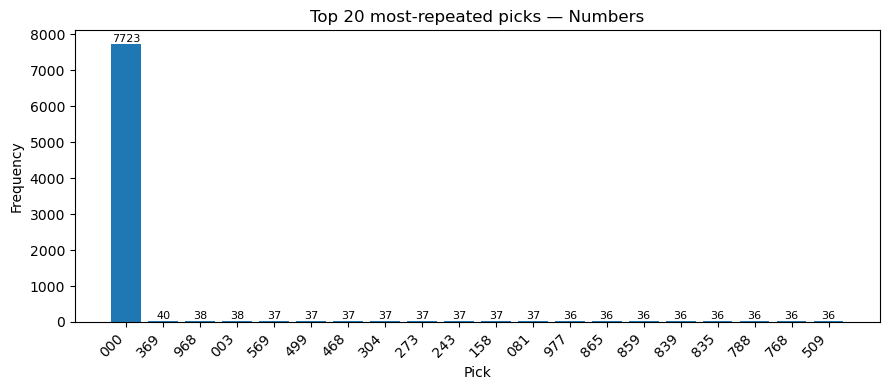

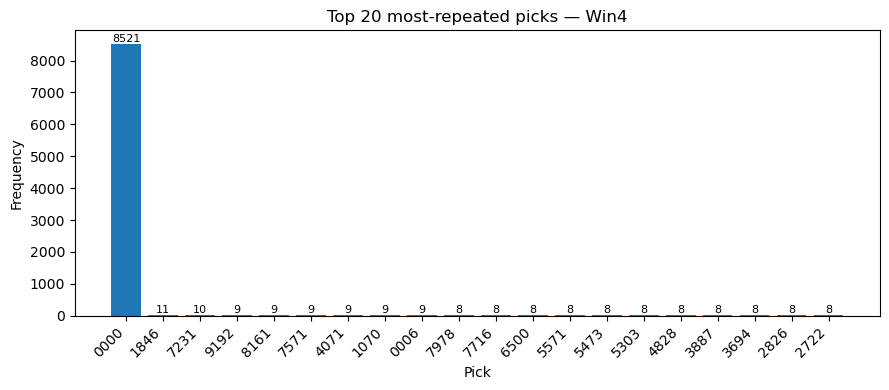

In [ ]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt
con = sqlite3.connect("../data/lottery_star.db")

def top_picks_by_game_id(game_id: int, title: str, top_n: int = 20):
    df = pd.read_sql("""
        SELECT pick, COUNT(*) AS freq
        FROM fact_daily_draws
        WHERE game_id = ?
        GROUP BY pick
        ORDER BY freq DESC
        LIMIT ?
    """, con, params=[game_id, top_n])

    if df.empty:
        print(f"[skip] no rows for game_id={game_id}")
        return

    df["pick"] = df["pick"].astype(str)
    plt.figure(figsize=(9,4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+1, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(title)
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# Numbers = 6, Win4 = 7
top_picks_by_game_id(6, "Top 20 most-repeated picks — Numbers", top_n=20)
top_picks_by_game_id(7, "Top 20 most-repeated picks — Win4",    top_n=20)


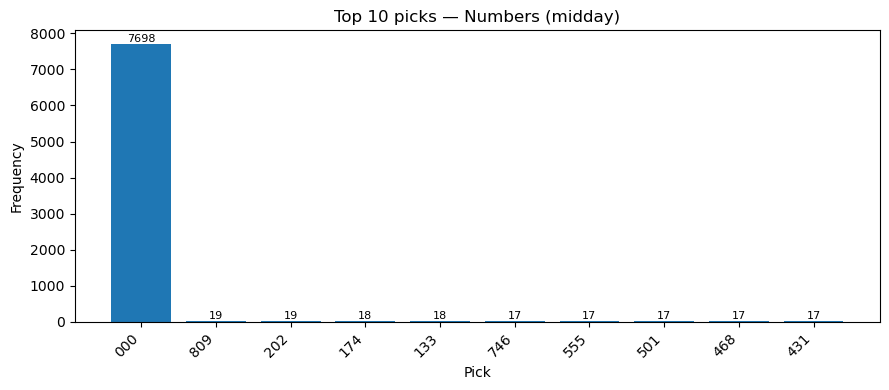

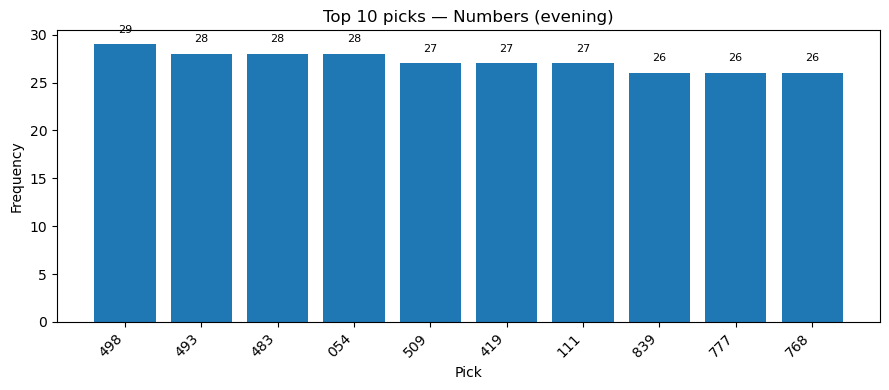

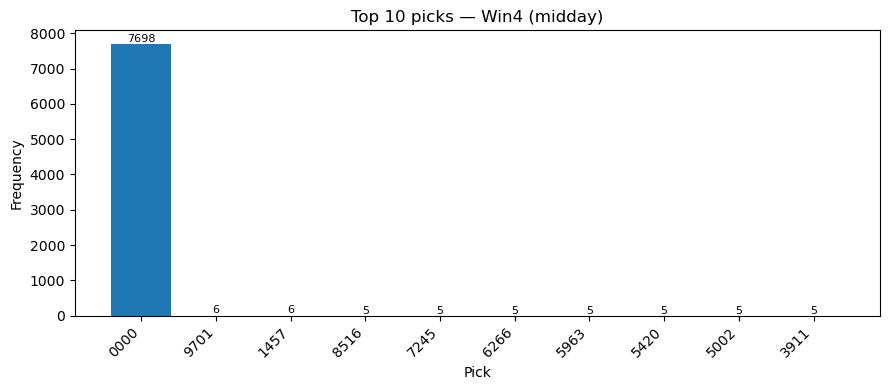

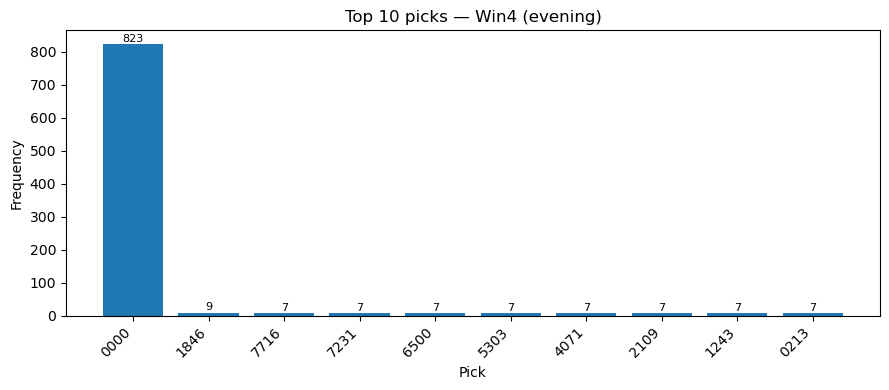

In [ ]:
def top_picks_by_session(game_id: int, session_name: str, top_n: int = 10):
    df = pd.read_sql("""
        SELECT f.pick, COUNT(*) AS freq
        FROM fact_daily_draws f
        JOIN dim_session s USING (session_id)
        WHERE f.game_id = ? AND s.session_name = ?
        GROUP BY f.pick
        ORDER BY freq DESC
        LIMIT ?
    """, con, params=[game_id, session_name, top_n])

    if df.empty:
        print(f"[skip] game_id={game_id} {session_name} empty"); return

    df["pick"] = df["pick"].astype(str)
    plt.figure(figsize=(9,4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+1, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Top {top_n} picks — {('Numbers' if game_id==6 else 'Win4')} ({session_name})")
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

for sess in ("midday","evening"):
    top_picks_by_session(6, sess, top_n=10)  # Numbers
for sess in ("midday","evening"):
    top_picks_by_session(7, sess, top_n=10)  # Win4


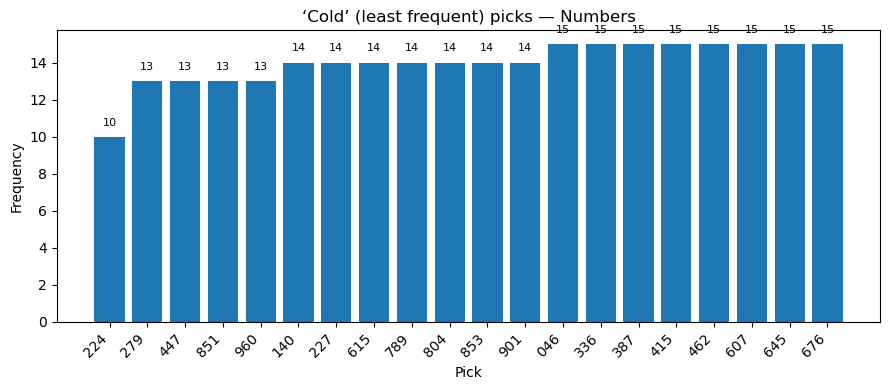

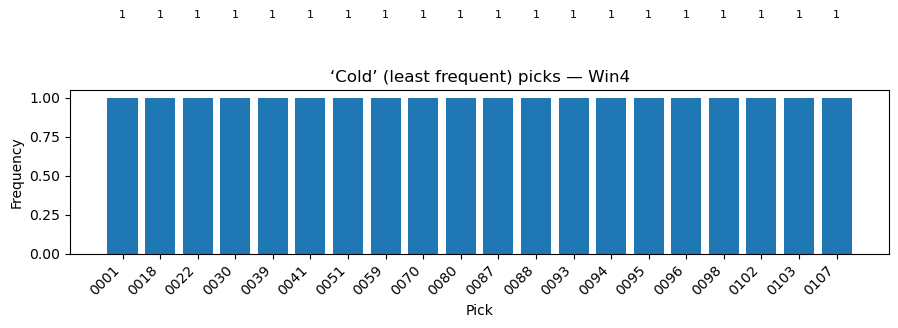

In [ ]:
def cold_picks(game_id: int, title: str, top_n: int = 20):
    df = pd.read_sql("""
        SELECT pick, COUNT(*) AS freq
        FROM fact_daily_draws
        WHERE game_id = ?
        GROUP BY pick
        HAVING freq >= 1
        ORDER BY freq ASC, pick ASC
        LIMIT ?
    """, con, params=[game_id, top_n])

    if df.empty:
        print(f"[skip] no rows for game_id={game_id}"); return

    df["pick"] = df["pick"].astype(str)
    plt.figure(figsize=(9,4))
    bars = plt.bar(df["pick"], df["freq"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+0.5, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(title)
    plt.xlabel("Pick"); plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

cold_picks(6, "‘Cold’ (least frequent) picks — Numbers", top_n=20)
cold_picks(7, "‘Cold’ (least frequent) picks — Win4",   top_n=20)


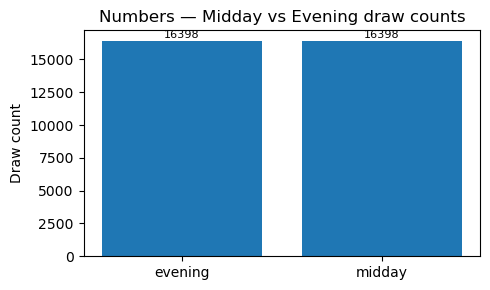

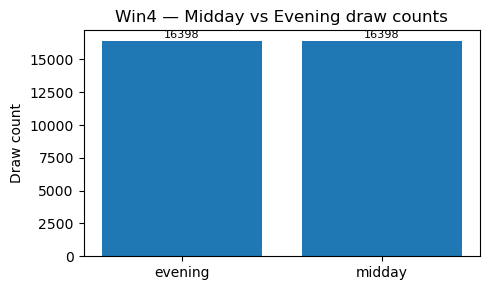

In [ ]:
def session_counts(game_id: int, title: str):
    df = pd.read_sql("""
        SELECT s.session_name, COUNT(*) AS draws
        FROM fact_daily_draws f
        JOIN dim_session s USING (session_id)
        WHERE f.game_id = ?
        GROUP BY s.session_name
    """, con, params=[game_id])

    if df.empty: 
        print(f"[skip] no rows for game_id={game_id}"); return

    plt.figure(figsize=(5,3))
    bars = plt.bar(df["session_name"], df["draws"])
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x()+b.get_width()/2, h+50, f"{int(h)}", ha="center", va="bottom", fontsize=8)
    plt.title(title); plt.ylabel("Draw count"); plt.tight_layout(); plt.show()

session_counts(6, "Numbers — Midday vs Evening draw counts")
session_counts(7, "Win4 — Midday vs Evening draw counts")


In [ ]:
df_numbers["pick_int"] = df_numbers["pick"].astype(int)
df_win4["pick_int"] = df_win4["pick"].astype(int)


In [ ]:
df_numbers["pick_int"] = df_numbers["pick"].astype(int)
df_win4["pick_int"] = df_win4["pick"].astype(int)

# Remove zero picks for clearer visualization
df_numbers_nz = df_numbers[df_numbers["pick_int"] != 0].copy()
df_win4_nz = df_win4[df_win4["pick_int"] != 0].copy()

print(f"Numbers draws (non-zero): {len(df_numbers_nz)} / {len(df_numbers)}")
print(f"Win4 draws (non-zero): {len(df_win4_nz)} / {len(df_win4)}")


Numbers draws (non-zero): 25073 / 32796
Win4 draws (non-zero): 24275 / 32796


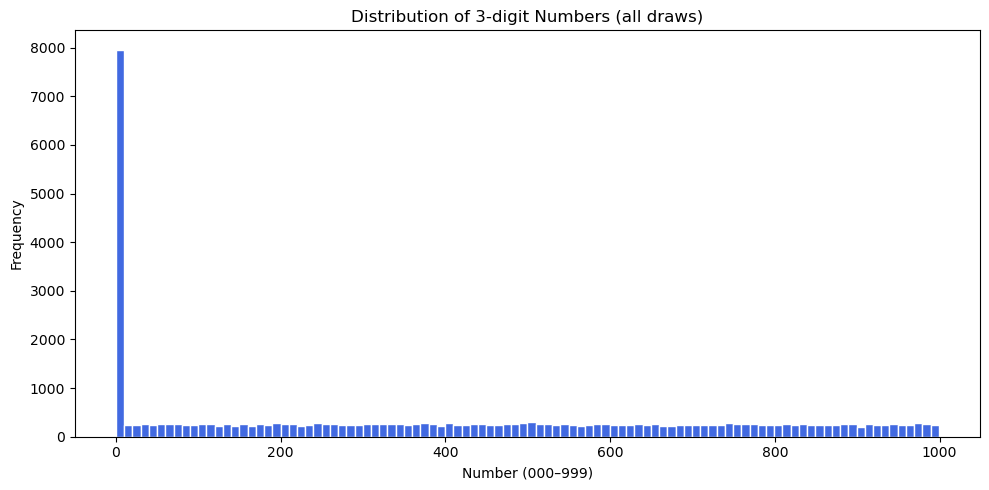

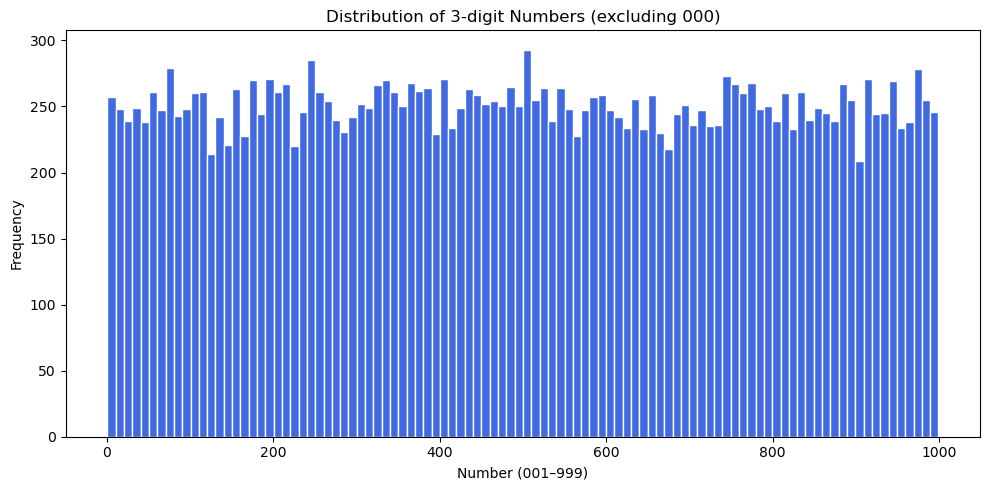

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df_numbers["pick_int"], bins=100, color="royalblue", edgecolor="white")
plt.title("Distribution of 3-digit Numbers (all draws)")
plt.xlabel("Number (000–999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_numbers_nz["pick_int"], bins=100, color="royalblue", edgecolor="white")
plt.title("Distribution of 3-digit Numbers (excluding 000)")
plt.xlabel("Number (001–999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


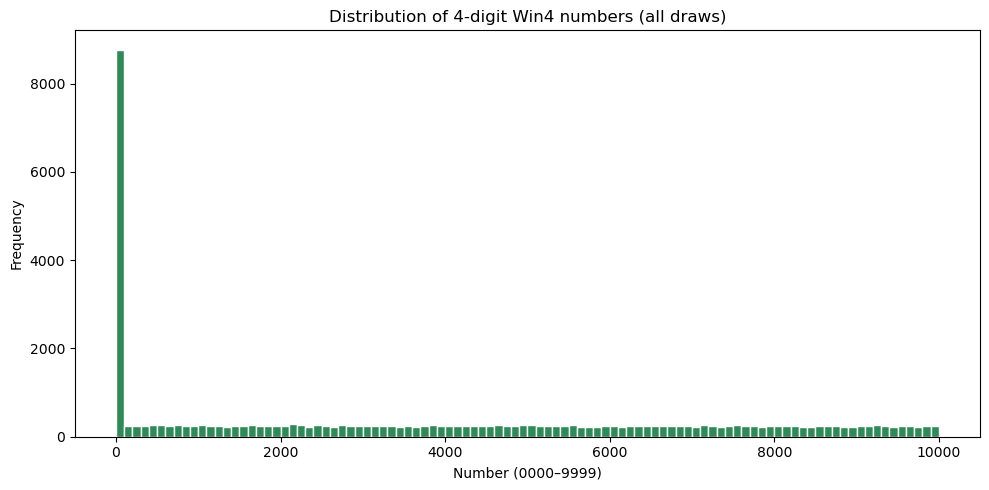

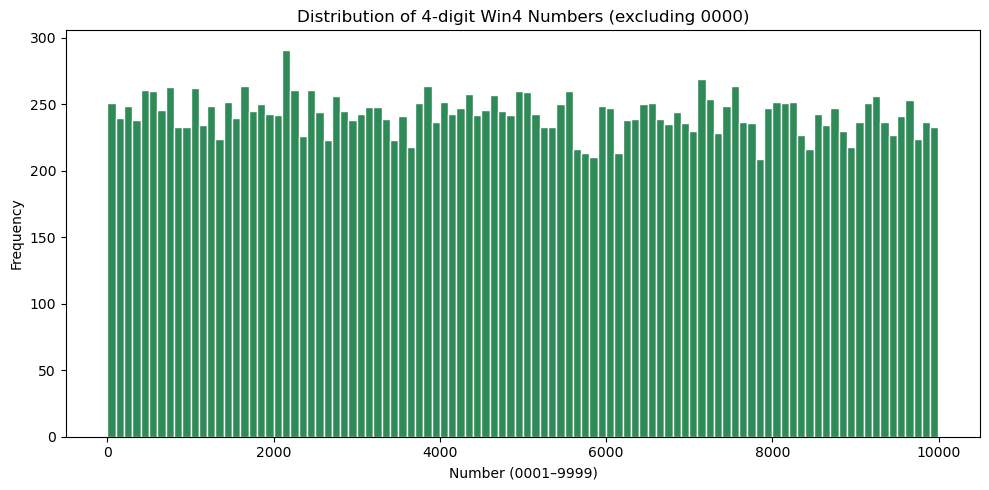

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df_win4["pick_int"], bins=100, color="seagreen", edgecolor="white")
plt.title("Distribution of 4-digit Win4 numbers (all draws)")
plt.xlabel("Number (0000–9999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.hist(df_win4_nz["pick_int"], bins=100, color="seagreen", edgecolor="white")
plt.title("Distribution of 4-digit Win4 Numbers (excluding 0000)")
plt.xlabel("Number (0001–9999)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


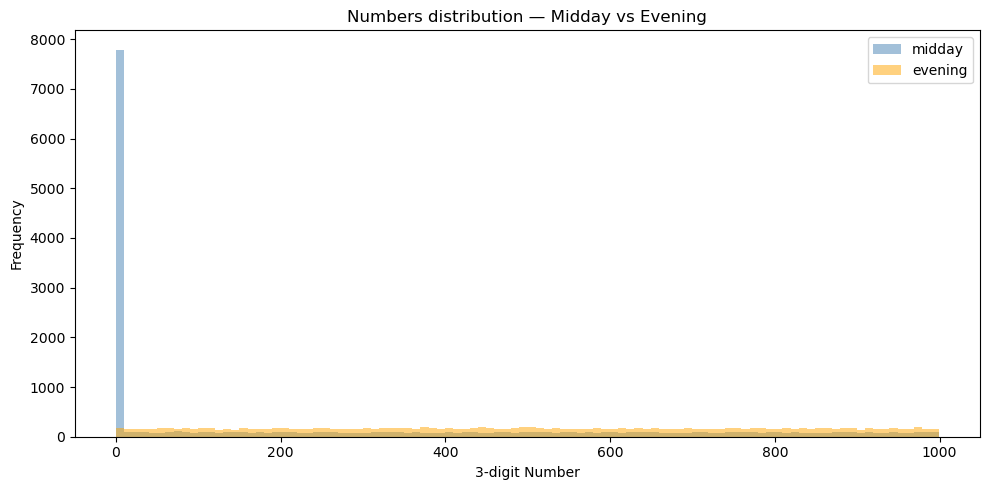

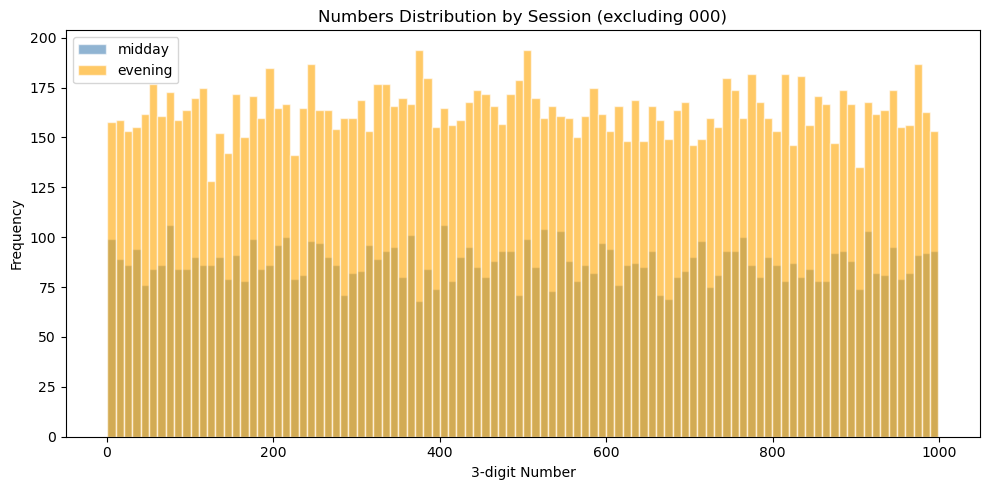

In [ ]:
plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["steelblue","orange"]):
    plt.hist(df_numbers.loc[df_numbers["session"]==sess, "pick_int"], bins=100, 
             alpha=0.5, label=sess, color=color)
plt.title("Numbers distribution — Midday vs Evening")
plt.xlabel("3-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["steelblue","orange"]):
    plt.hist(df_numbers_nz.loc[df_numbers_nz["session"]==sess, "pick_int"],
             bins=100, alpha=0.6, label=sess, color=color, edgecolor="white")
plt.title("Numbers Distribution by Session (excluding 000)")
plt.xlabel("3-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


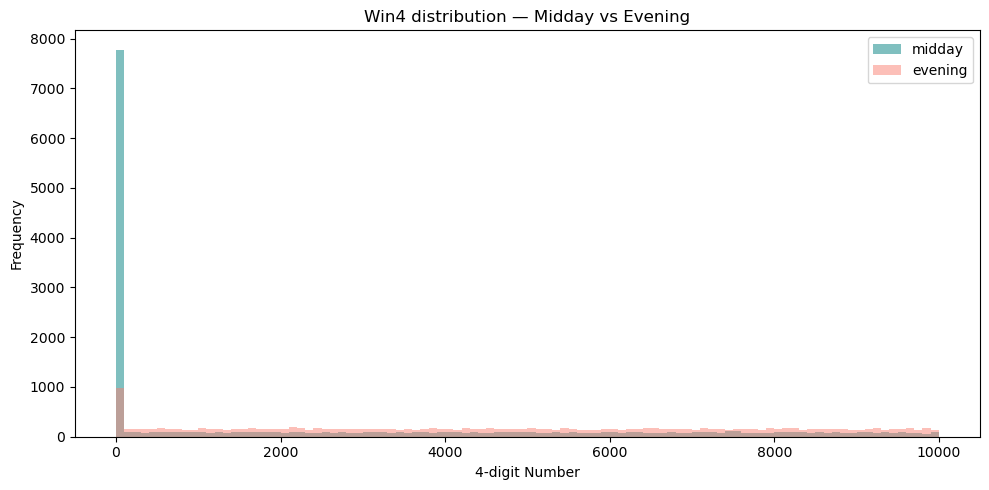

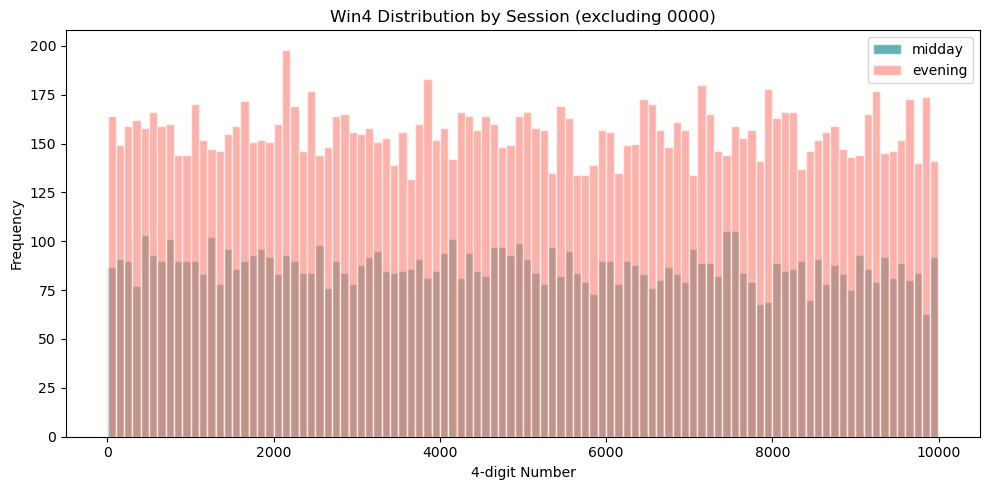

In [ ]:
plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["teal","salmon"]):
    plt.hist(df_win4.loc[df_win4["session"]==sess, "pick_int"], bins=100, 
             alpha=0.5, label=sess, color=color)
plt.title("Win4 distribution — Midday vs Evening")
plt.xlabel("4-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
for sess, color in zip(["midday","evening"], ["teal","salmon"]):
    plt.hist(df_win4_nz.loc[df_win4_nz["session"]==sess, "pick_int"],
             bins=100, alpha=0.6, label=sess, color=color, edgecolor="white")
plt.title("Win4 Distribution by Session (excluding 0000)")
plt.xlabel("4-digit Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Numbers Game Stats:")
print(df_numbers["pick_int"].describe().apply(lambda x: format(x, ".2f")))
print("\nWin4 Game Stats:")
print(df_win4["pick_int"].describe().apply(lambda x: format(x, ".2f")))


Numbers Game Stats:
count    32796.00
mean       381.56
std        328.90
min          0.00
25%         19.75
50%        346.00
75%        670.00
max        999.00
Name: pick_int, dtype: object

Win4 Game Stats:
count    32796.00
mean      3669.83
std       3300.74
min          0.00
25%          0.00
50%       3184.00
75%       6575.00
max       9999.00
Name: pick_int, dtype: object


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df_numbers["draw_date"] = pd.to_datetime(df_numbers["draw_date"])
df_win4["draw_date"] = pd.to_datetime(df_win4["draw_date"])

# Filter only zero picks
zero_numbers = df_numbers[df_numbers["pick_int"] == 0].copy()
zero_win4 = df_win4[df_win4["pick_int"] == 0].copy()

# Group by month
zero_numbers["month"] = zero_numbers["draw_date"].dt.to_period("M")
zero_win4["month"] = zero_win4["draw_date"].dt.to_period("M")

freq_zero = (
    pd.DataFrame({
        "numbers_zero": zero_numbers.groupby("month").size(),
        "win4_zero": zero_win4.groupby("month").size()
    })
    .fillna(0)
    .astype(int)
    .reset_index()
)
freq_zero["month"] = freq_zero["month"].astype(str)
freq_zero.tail(10)


,month,numbers_zero,win4_zero
272,2012-01,1,0
273,2013-04,1,0
274,2015-03,1,0
275,2016-05,1,0
276,2016-11,1,0
277,2019-01,1,0
278,2019-05,1,0
279,2023-07,1,0
280,2024-05,1,0
281,2024-12,1,0


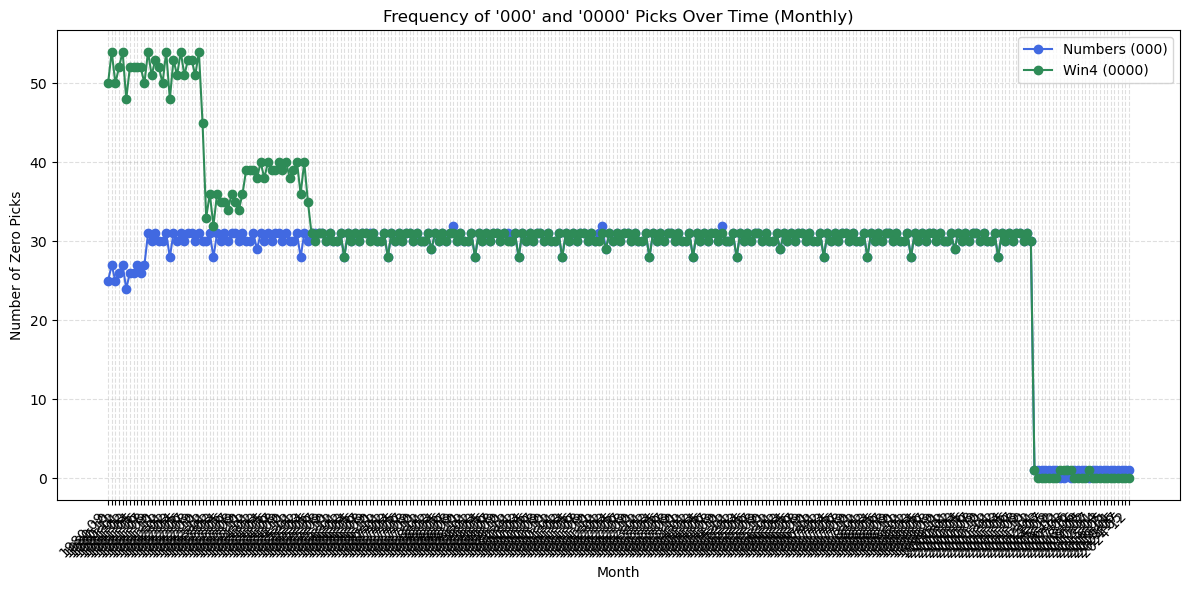

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(freq_zero["month"], freq_zero["numbers_zero"], label="Numbers (000)", color="royalblue", marker="o")
plt.plot(freq_zero["month"], freq_zero["win4_zero"], label="Win4 (0000)", color="seagreen", marker="o")

plt.title("Frequency of '000' and '0000' Picks Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Zero Picks")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



In [ ]:
zero_yearly = (
    pd.DataFrame({
        "numbers_zero": zero_numbers.groupby(zero_numbers["draw_date"].dt.year).size(),
        "win4_zero": zero_win4.groupby(zero_win4["draw_date"].dt.year).size()
    })
    .fillna(0)
    .astype(int)
    .rename_axis("year")
    .reset_index()
)
display(zero_yearly)


,year,numbers_zero,win4_zero
0,1980,103,206
1,1981,335,620
2,1982,364,600
3,1983,364,427
4,1984,365,469
5,1985,365,395
6,1986,365,364
7,1987,364,364
8,1988,366,365
9,1989,365,364


In [ ]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt

con = sqlite3.connect("../data/lottery_star.db")

# --- Load all Powerball numbers (each draw_id has 6 numbers: 5 main + 1 bonus) ---
df_powerball = pd.read_sql("""
SELECT f.draw_date, f.number, f.game_id
FROM fact_set_numbers f
JOIN dim_game g USING (game_id)
WHERE LOWER(g.game_name) = 'powerball'
ORDER BY f.draw_date, f.number;
""", con)

df_powerball["draw_date"] = pd.to_datetime(df_powerball["draw_date"])
df_powerball.head()


,draw_date,number,game_id
0,2010-02-03,17,2
1,2010-02-03,22,2
2,2010-02-03,36,2
3,2010-02-03,37,2
4,2010-02-03,52,2


In [ ]:
# Rank numbers within each draw
df_powerball["rank_in_draw"] = df_powerball.groupby("game_id")["number"].rank(method="first")

# 6th number → bonus ball
main = df_powerball[df_powerball["rank_in_draw"] <= 5]
bonus = df_powerball[df_powerball["rank_in_draw"] == 6]


In [ ]:
freq_main = main["number"].value_counts().sort_index()
freq_bonus = bonus["number"].value_counts().sort_index()


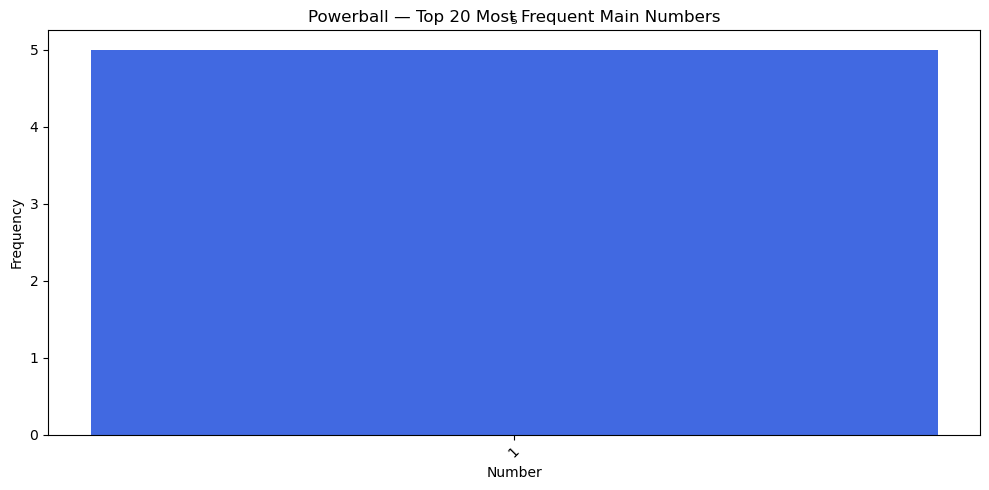

In [ ]:
freq_main = main["number"].value_counts().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,5))
bars = plt.bar(freq_main.index.astype(str), freq_main.values, color="royalblue")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{int(b.get_height())}",
             ha="center", va="bottom", fontsize=8)
plt.title("Powerball — Top 20 Most Frequent Main Numbers")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


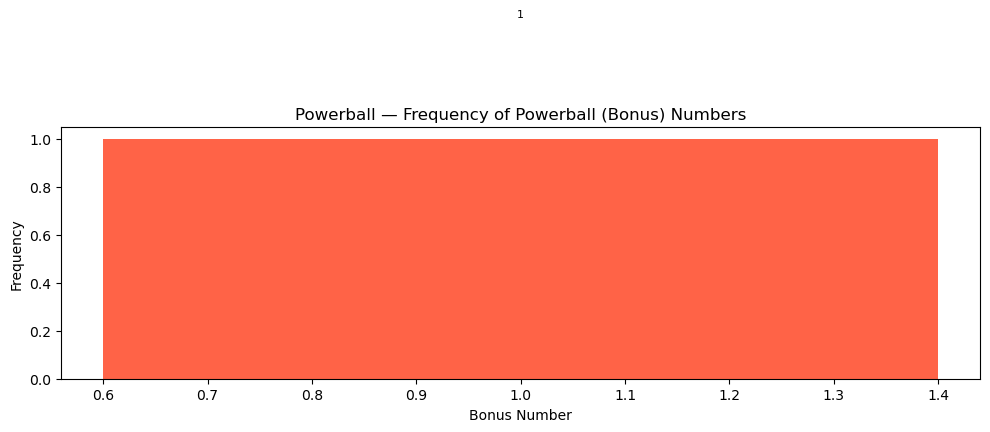

In [ ]:
plt.figure(figsize=(10,5))
bars = plt.bar(freq_bonus.index, freq_bonus.values, color="tomato")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{int(b.get_height())}",
             ha="center", va="bottom", fontsize=8)
plt.title("Powerball — Frequency of Powerball (Bonus) Numbers")
plt.xlabel("Bonus Number")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


C:\Users\Gurram Yashaswi\AppData\Local\Temp\ipykernel_20448\1870038530.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main["year"] = main["draw_date"].dt.year


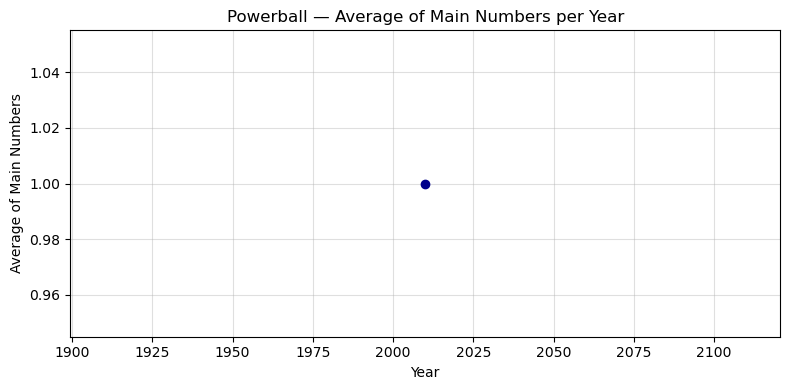

In [ ]:
main["year"] = main["draw_date"].dt.year
avg_per_year = main.groupby("year")["number"].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_per_year["year"], avg_per_year["number"], marker="o", color="darkblue")
plt.title("Powerball — Average of Main Numbers per Year")
plt.xlabel("Year")
plt.ylabel("Average of Main Numbers")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


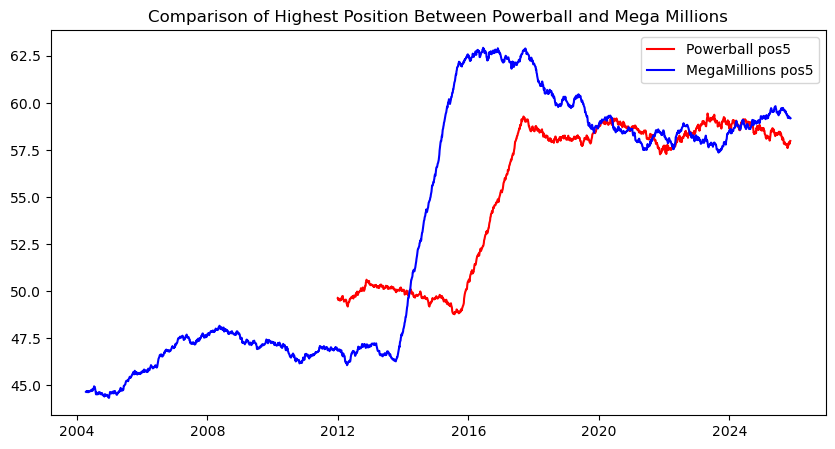

In [45]:
df = pd.read_sql("""
SELECT f.draw_date, f.number, f.position
FROM fact_set_numbers f
JOIN dim_game USING (game_id)
WHERE LOWER(game_name) = 'powerball'
ORDER BY f.draw_date, f.position;
""", con)

df["draw_date"] = pd.to_datetime(df["draw_date"])
pos_df = df.pivot(index="draw_date", columns="position", values="number")
pos_df.columns = [f"pos{i}" for i in pos_df.columns]

df_mm = pd.read_sql("""
SELECT f.draw_date, f.number, f.position
FROM fact_set_numbers f
JOIN dim_game USING (game_id)
WHERE LOWER(game_name) = 'mega_millions'
ORDER BY f.draw_date, f.position;
""", con)
df_mm["draw_date"] = pd.to_datetime(df_mm["draw_date"])
pos_mm = df_mm.pivot(index="draw_date", columns="position", values="number")
pos_mm.columns = [f"pos{i}" for i in pos_mm.columns]

plt.figure(figsize=(10,5))
plt.plot(pos_df["pos5"].rolling(200).mean(), label="Powerball pos5", color="red")
plt.plot(pos_mm["pos5"].rolling(200).mean(), label="MegaMillions pos5", color="blue")
plt.title("Comparison of Highest Position Between Powerball and Mega Millions")
plt.legend()
plt.show()
